In [1]:
!pip install datasets
!pip install -U datasets
!pip install tiktoken



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

In [3]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

encoder = tiktoken.get_encoding("gpt2")

def process(example):
  ids = encoder.encode_ordinary(example["text"])
  output = {'ids': ids, 'len': len(ids)}
  return output


if not os.path.exists("train.bin"):
  tokenized = ds.map(
      process,
      remove_columns = ["text"],
      desc = "tokenizing the splits",
      num_proc = 8,
  )

  for split,dset in tokenized.items():
    arr_len = np.sum(dset['len'], dtype = np.uint64)
    filename = f'{split}.bin'
    dtype = np.uint16
    arr = np.memmap(filename, dtype = dtype, mode = "w+", shape = (arr_len,))
    total_batches = 1024

    idx = 0
    for batch_idx in tqdm(range(total_batches), desc = f'writing {filename}'):
      batch = dset.shard(num_shards = total_batches, index = batch_idx, contiguous = True).with_format('numpy')
      arr_batch = np.concatenate(batch['ids'])
      arr[idx:idx+len(arr_batch)] = arr_batch
      idx += len(arr_batch)
    arr.flush()

In [4]:
import torch

def compute_rope_params(head_dim, theta_base = 10_000, context_length = 4096,dtype = torch.float32):
  assert head_dim%2==0, "Embedding dimension must be even"

  inv_freq = 1.0 / (theta_base ** (torch.arange(0,head_dim,2,dtype = dtype)[: (head_dim//2)].float()/head_dim))

  positions = torch.arange(context_length,dtype = dtype)
  angles = positions[:,None]  * inv_freq[None, :]

  angles = torch.cat([angles,angles],dim=1)

  cos = torch.cos(angles)
  sin = torch.sin(angles)
  return cos,sin

def apply_rope(x,cos,sin):
  batch_size, num_heads, seq_length ,  head_dim = x.shape
  assert head_dim%2==0 , "Head Dimension must be even"

  x1 = x[..., : head_dim//2]
  x2 = x[..., head_dim//2:]

  cos = cos[:seq_length,:].unsqueeze(0).unsqueeze(0)
  sin = sin[:seq_length,:].unsqueeze(0).unsqueeze(0)

  rotated = torch.cat((-x2,x1),dim=-1)
  x_rotated = (x*cos) + (rotated*sin)

  return x_rotated.to(dtype = x.dtype)


In [5]:
import torch
def get_batch(split):
  if split=="train":
    data = np.memmap('train.bin',dtype=np.uint16,mode='r')
  else:
    data = np.memmap('validation.bin',dtype=np.uint16,mode = 'r')
  ix = torch.randint(0, len(data)-block_size, (batch_size,))
  x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64))for i in ix])
  y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
  if device_type =="cuda":
    x,y = x.pin_memory().to(device,non_blocking = True) , y.pin_memory().to(device,non_blocking = True)
  else:
    x,y = x.to(device), y.to(device)
  return x,y

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class RMSNorm(nn.Module):
  def __init__(self,emb_dim,eps=1e-6,bias = False):
    super().__init__()
    self.eps = eps
    self.scale = nn.Parameter(torch.zeros(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

  def forward(self,x):
    input_dtype = x.dtype
    x_f = x.float()
    var = x_f.pow(2).mean(dim=-1,keepdim = True)
    x_norm = x_f * torch.rsqrt(var + self.eps)
    out = x_norm * (1.0 + self.scale.float())

    if self.shift is not None:
      out = out + self.shift.float()

    return out.to(input_dtype)

class GroupedQueryAttention(nn.Module):
  def __init__(
      self,d_in, num_heads, num_kv_groups, head_dim = None,qk_norm = False,
      query_pre_attn_scalar = None, dtype =None,
  ):
    super().__init__()
    assert num_heads % num_kv_groups == 0 , "num_heads must be divisible by num_kv_groups"

    self.num_heads = num_heads
    self.num_kv_groups = num_kv_groups
    self.group_size = num_heads // num_kv_groups

    if head_dim is None:
      assert d_in % num_heads == 0 , "d_in must be divisible by num_heads"
      head_dim = d_in //num_heads

    self.head_dim = head_dim
    self.d_out = num_heads * head_dim

    self.w_query = nn.Linear(d_in,self.d_out , bias = False,dtype= dtype)
    self.w_key = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)
    self.w_value = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)

    self.out_proj = nn.Linear(self.d_out , d_in , bias = False, dtype= dtype)

    if qk_norm:
      self.q_norm = RMSNorm(head_dim , eps = 1e-6)
      self.k_norm = RMSNorm(head_dim , eps = 1e-6)
    else:
      self.q_norm = self.k_norm = None

    if query_pre_attn_scalar is not None:
      self.scaling = (query_pre_attn_scalar) ** -0.5
    else:
      self.scaling = (head_dim) ** -0.5

  def forward(self,x, mask,cos,sin):
    b , num_tokens, _  = x.shape

    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)


    queries = queries.view(b, num_tokens , self.num_heads,self.head_dim).transpose(1,2)
    keys = keys.view(b,num_tokens, self.num_kv_groups,self.head_dim).transpose(1,2)
    values = values.view(b,num_tokens , self.num_kv_groups,self.head_dim).transpose(1,2)

    if self.q_norm:
      queries = self.q_norm(queries)
    if self.k_norm:
      keys = self.k_norm(keys)

    queries = apply_rope(queries,cos,sin)
    keys = apply_rope(keys,cos,sin)

    keys = keys.repeat_interleave(self.group_size,dim = 1)
    values = values.repeat_interleave(self.group_size, dim =1)

    queries = queries * self.scaling

    attn_scores = queries @ keys.transpose(2,3)
    attn_scores = attn_scores.masked_fill(mask,-torch.inf)
    attn_weights = torch.softmax(attn_scores,dim=-1)

    context = (attn_weights @ values).transpose(1,2).reshape(b,num_tokens,self.d_out)
    return self.out_proj(context)

class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.fc1 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc2 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc3 = nn.Linear(cfg["hidden_dim"],cfg["emb_dim"],dtype = cfg["dtype"],bias = False)

  def forward(self,x):
    x_fc1 = self.fc1(x)
    x_fc2 = self.fc2(x)
    x = nn.functional.gelu(x_fc1,approximate = "tanh") * x_fc2
    return self.fc3(x)

class TransformerBlock(nn.Module):
  def __init__(self,cfg:dict,attn_type:str):
    super().__init__()
    self.attn_type = attn_type
    self.attn = GroupedQueryAttention(
        d_in = cfg["emb_dim"],
        num_heads = cfg["n_heads"],
        num_kv_groups = cfg["n_kv_groups"],
        head_dim = cfg["head_dim"],
        qk_norm = cfg["qk_norm"],
        query_pre_attn_scalar = cfg["query_pre_attn_scalar"],
        dtype = cfg["dtype"],
    )

    self.ff = FeedForward(cfg)
    self.input_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_attention_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.pre_feedforward_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_feedforward_layernorm = RMSNorm(cfg["emb_dim"] , eps = 1e-6)

  def forward(self,x,mask_global,mask_local,cos_global,sin_global,cos_local,sin_local):
    shortcut = x
    x = self.input_layernorm(x)

    if self.attn_type =="sliding_attention":
      attn_mask = mask_local
      cos = cos_local
      sin = sin_local
    else:
      attn_mask = mask_global
      cos = cos_global
      sin = sin_global

    x_attn = self.attn(x,attn_mask,cos,sin)
    x_attn = self.post_attention_layernorm(x_attn)
    x = shortcut + x_attn

    shortcut = x
    x_ffn = self.pre_feedforward_layernorm(x)
    x_ffn = self.ff(x_ffn)
    x_ffn = self.post_feedforward_layernorm(x_ffn)
    x = shortcut + x_ffn
    return x

class Gemma3Model(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    assert cfg["layer_types"] is not None and len(cfg["layer_types"]) == cfg["n_layers"]

    self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"],dtype = cfg["dtype"])

    self.blocks = nn.ModuleList([
        TransformerBlock(cfg,attn_type) for attn_type in cfg["layer_types"]
    ])


    self.final_norm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"],bias = False, dtype = cfg["dtype"])
    self.cfg = cfg

    cos_local , sin_local = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_local_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )

    cos_global , sin_global = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_global_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )
    self.register_buffer("cos_local", cos_local , persistent = False)
    self.register_buffer("sin_local", sin_local , persistent = False)
    self.register_buffer("cos_global", cos_global , persistent = False)
    self.register_buffer("sin_global", sin_global , persistent = False)
  
  def _create_masks(self,seq_len, device):
    ones = torch.ones((seq_len,seq_len), dtype=torch.bool, device=device)
    mask_global = torch.triu(ones, diagonal=1)
    mask_local = torch.triu(ones, diagonal=1) | torch.tril(ones, diagonal=-self.cfg["sliding_window"])  
    return mask_global, mask_local

    
  def forward(self,input_ids,targets = None):
    b,seq_len  = input_ids.shape
    x = self.tok_emb(input_ids) * (self.cfg["emb_dim"]**0.5)
    mask_global , mask_local = self._create_masks(seq_len,x.device)

    for block in self.blocks:
      x = block(
          x,
          mask_global = mask_global,
          mask_local= mask_local,
          cos_global = self.cos_global,
          sin_global = self.sin_global,
          cos_local = self.cos_local,
          sin_local = self.sin_local,
      )
    x = self.final_norm(x)
    logits = self.out_head(x.to(self.cfg["dtype"]))
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.reshape(-1,logits.size(-1)),targets.reshape(-1))
    return logits,loss


  @torch.no_grad()
  def generate(self,idx,max_new_tokens,temperature = 1.0,top_k = None):
    for _ in range(max_new_tokens):
      ctx_len = self.cfg["context_length"]
      idx_cond = idx if idx.size(1) <= ctx_len else idx[:,-ctx_len:]
      logits , _ = self(idx_cond)
      logits = logits[:,-1,:]/ temperature
      if top_k is not None:
        v , _ = torch.topk(logits, min(top_k,logits.size(-1)))
        logits[logits< v[:,[-1]]] = float('-inf')
      probs = F.softmax(logits,dim=-1)
      idx_next = torch.multinomial(probs,num_samples = 1)
      idx  = torch.cat((idx,idx_next),dim=1)
    return idx




In [7]:
GEMMA3_CONFIG_270M= {
    "vocab_size": 50257,
    "context_length": 32768,
    "emb_dim": 640,
    "n_heads": 4,
    "n_layers": 18,
    "hidden_dim": 2048,
    "head_dim": 256,
    "qk_norm": True,
    "n_kv_groups": 1,
    "rope_local_base": 10000.0,
    "rope_global_base": 1000000.0,
    "sliding_window": 4096,
    "layer_types": [
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
    ],
    "dtype": torch.bfloat16,
    "query_pre_attn_scalar": 256,
}

torch.manual_seed(123)
model = Gemma3Model(GEMMA3_CONFIG_270M)

In [8]:
def estimate_loss(model):
  out = {}
  model.eval()
  with torch.inference_mode():
    for split in ['train','val']:
      losses = torch.zeros(eval_iters)
      for k in range(eval_iters):
        x,y = get_batch(split)
        with ctx:
          logits, loss = model(x,y)
        losses[k] = loss.item()
      out[split] = losses.mean()
  model.train()
  return out

In [9]:
import torch
from contextlib import nullcontext
learning_rate = 1e-4
max_iters = 150000
warmup_steps = 1000
min_lr = 5e-4
eval_iters = 500
batch_size = 32
block_size = 128

gradient_accumulation_steps = 32

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"
ptdtype = {'float32': torch.float32,'bfloat16': torch.bfloat16,'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type =="cpu" else torch.amp.autocast(device_type = device_type,dtype = ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [10]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters() , lr = learning_rate, betas = (0.9,0.95),weight_decay = 0.1, eps = 1e-9)

scheduler_warmup = LinearLR(optimizer,total_iters = warmup_steps)
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps,eta_min = min_lr)
scheduler = SequentialLR(optimizer, schedulers = [scheduler_warmup,scheduler_decay],milestones = [warmup_steps])

scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

In [19]:
import os
import torch
from tqdm import tqdm

best_model_params_path = "best_model_params.pt"
interrupt_checkpoint_path = "resume_checkpoint.pt"

start_epoch = 0
best_val_loss = float('inf')
train_loss_list, validation_loss_list = [], []

model = model.to(device)

if os.path.exists(interrupt_checkpoint_path):
    print(f"Found interrupt checkpoint. Resuming training...")
    checkpoint = torch.load(interrupt_checkpoint_path)
    
    # Restore model, optimizer, scaler, and scheduler states
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    train_loss_list = checkpoint['train_loss_list']
    validation_loss_list = checkpoint['validation_loss_list']
    print(f"Successfully resumed. Starting from iteration {start_epoch}.")
else:
    print("No resume checkpoint found. Starting from scratch.")


try:
    for epoch in tqdm(range(start_epoch, max_iters), initial=start_epoch, total=max_iters):
        
        if epoch % eval_iters == 0 and epoch != 0:
            model.eval() 
            losses = estimate_loss(model)
            model.train() 
            
            print(f"Epoch {epoch}: train_loss {losses['train']:.4f} , val_loss {losses['val']:.4f}")
            print(f"The Current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
            
            train_loss_list.append(losses['train'].item())
            validation_loss_list.append(losses['val'].item())

            if losses['val'] < best_val_loss:
                best_val_loss = losses['val']
                torch.save(model.state_dict(), best_model_params_path)

        x, y = get_batch('train')
        x, y = x.to(device), y.to(device)

        with ctx:
            logits, loss = model(x, y)
            loss = loss / gradient_accumulation_steps
            
        scaler.scale(loss).backward()

        if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()

except KeyboardInterrupt:
    print(f"\n[!] Training interrupted by user at iteration {epoch}.")
    print("Saving full state to resume later...")

    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'train_loss_list': train_loss_list,
        'validation_loss_list': validation_loss_list
    }, interrupt_checkpoint_path)
    
    print("State saved! You can now run inference.")

Found interrupt checkpoint. Resuming training...
Successfully resumed. Starting from iteration 44438.


 30% 44500/150000 [00:08<4:09:35,  7.05it/s]

Epoch 44500: train_loss 2.8866 , val_loss 2.8843
The Current learning rate: 0.00010


 30% 45001/150000 [02:40<316:03:14, 10.84s/it]

Epoch 45000: train_loss 2.8955 , val_loss 2.8913
The Current learning rate: 0.00010


...

Epoch 47500: train_loss 2.8904 , val_loss 2.8964
The Current learning rate: 0.00010


 32% 48001/150000 [14:17<435:59:11, 15.39s/it]

Epoch 48000: train_loss 2.8864 , val_loss 2.8937
The Current learning rate: 0.00010


 32% 48465/150000 [15:23<6:27:56,  4.36it/s]  



[!] Training interrupted by user at iteration 48465.
Saving full state to resume later...
State saved! You can now run inference.


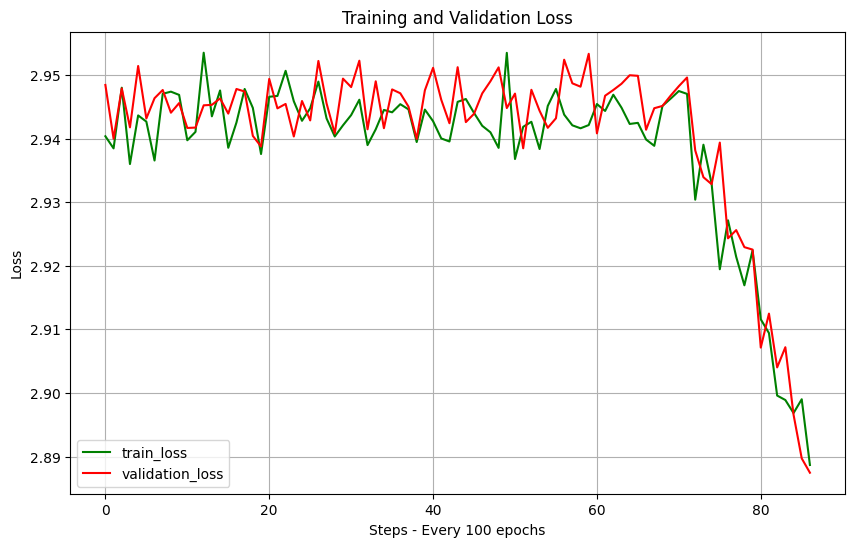

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(train_loss_list, 'g', label='train_loss')
plt.plot(validation_loss_list, 'r', label='validation_loss')

plt.title("Training and Validation Loss")
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) 
plt.show()

In [20]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Gemma3Model(GEMMA3_CONFIG_270M)
model = model.to(device) 


best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device), weights_only=True)) 
model.eval() 


sentence = "Once upon a time there was a pumpkin."
context = torch.tensor(encoder.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)

with torch.no_grad(): 
    y = model.generate(context, 500)

print(encoder.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. Every day, it lived One day long. It was a tiny beautiful yellow fish. One day it embarrassment and time, it started to get a new. The music was cold, so the beach guarding ourselves. The cat time, the cat saw the clay. The river knew he had to climb the cat so he wouldn't get to touch its destination. So he watched the bear and played hide snacks. 

When she soon said, "Yuck got to use his worries surprise. You have to raise it everywhere tag and enjoy some snacks." The two best friends decided to celebrate Lily. They knew they had a finea nodded that finally made him free to pick it up. 

A mouse was very happy and they had ever coming to eat. They hugged the mouse with lots of people shoes. 

One day, a little girl agreed. She wanted to wear the Become and buy a picture of a lazy. She pushed her sheet and waited through the door. She ran to the door and magazine this time again. 

Suddenly one day, the dad smiles's tail. He was ready when heled 

In [1]:


!pip install huggingface_hub




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from huggingface_hub import notebook_login
notebook_login()



In [ ]:
from huggingface_hub import login, HfApi

api = HfApi()
repo_id = "Parthiban007/Gemma_3_270M"





# 3. List of files to upload
files_to_push = [
    "best_model_params.pt", 
    "resume_checkpoint.pt", 
    "train.bin", 
    "validation.bin",
    "gemma_3.ipynb"
]


# 4. Upload loop
for file_name in files_to_push:
    print(f"Uploading {file_name}...")
    try:
        api.upload_file(
            path_or_fileobj=file_name,
            path_in_repo=file_name,
            repo_id=repo_id,
        )
        
        print(f"✅ Successfully uploaded {file_name}")
    except Exception as e:
        
        print(f"❌ Failed to upload {file_name}: {e}")

print(f"\n🚀 All done! View your model at: https://huggingface.co/{repo_id}")

Uploading best_model_params.pt...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  best_model_params.pt                  :  20%|##        | 67.1MB /  330MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Successfully uploaded resume_checkpoint.pt
Uploading train.bin...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  train.bin                             :   7%|7         | 67.1MB /  944MB            